# Recommender for FINN.no

**Part 3 of FINN marketplace analytics project.**  Real FINN data only, no simulation.

This recommender gives each buyer a top 10 of listings. ALS picks 200 candidates
from the buyer's first 5 interactions, then a LightGBM model (option B) re-orders them. It beats simple
baselines by a wide margin and beats ALS alone by a small but real margin. A second way to train LightGBM
(option A) did not work and was dropped. The gain is measured offline only, so the next step is a live
A/B test, not a launch.

**How this notebook works:** Follow the notebook cell sequence. The tuning and the final test is done by the scripts in `recommender/`. This notebook reads the results they saved
and the tables they wrote to Snowflake, so it runs in minutes.

## 1. The question

- **Where:** the recommendation slates on FINN (the "recommended for you" lists).
- **Goal:** rank the listings a buyer is most likely to click higher.
- **Target:** real clicks. They stand in for interest, because seller contacts are not in the data.
- **Must beat:** two simple baselines, popularity and category popularity.
- **Good means:** the buyer's next click (and later clicks) is inside our top 10, and high in it.

## 2. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
while not (ROOT / "dbt_project").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / ".env", override=True)

from analysis.snowflake_io import database, query
from recommender import data, metrics

RESULTS = ROOT / "analysis" / "results"
print("Reading Snowflake tables from:", database())

BLUE, ORANGE, GREY, RED = "#2a78d6", "#eb6834", "#8a8f98", "#c0392b"
MODEL_ORDER = ["popularity", "category_popularity", "als", "als_lgbm_a", "als_lgbm_b"]
MODEL_LABELS = {
    "popularity": "Popularity",
    "category_popularity": "Category popularity",
    "als": "ALS alone",
    "als_lgbm_a": "ALS + LightGBM A",
    "als_lgbm_b": "ALS + LightGBM B",
}
MODEL_COLOURS = {
    "popularity": GREY, "category_popularity": GREY, "als": BLUE,
    "als_lgbm_a": RED, "als_lgbm_b": ORANGE,
}
pd.options.display.float_format = "{:.4f}".format
pd.options.display.width = 140


def load(name):
    return pd.read_csv(RESULTS / name)


needed = [
    "rec_baselines_validation.csv", "rec_als_tuning_validation.csv", "rec_als_best_params.json",
    "rec_lgbm_b_tuning_validation.csv", "rec_lgbm_a_tuning_validation.csv",
    "rec_slate_check_validation.csv", "rec_eval_test_top10.csv", "rec_eval_test_differences.csv",
    "rec_eval_test_slates.csv", "rec_eval_test_lists.csv",
]
missing = [name for name in needed if not (RESULTS / name).exists()]
print("All result files found." if not missing else f"Missing result files: {missing}")

Reading Snowflake tables from: DEV
All result files found.


## 3. The workflow

```
FINN slate data (real, 113,404 buyers)
  -> Snowflake RAW -> dbt cleans it
  -> dbt: split buyers into train / validation / test, mark first 5 actions vs later actions
  -> dbt: tables of training rows, buyer features, listing features
  -> Baselines: popularity, category popularity
  -> Stage 1, ALS: learn taste from first-5 clicks, pick 200 candidates per buyer
  -> Stage 2, LightGBM: re-order the 200 into a top 10
        option A: trained on listings FINN showed          (dropped)
        option B: trained on ALS's own 200 candidates      (kept)
  -> Choose all settings on VALIDATION buyers
  -> Final test on TEST buyers, once, all models on the same buyers
  -> Write the top 10 lists to Snowflake (RAW.RECOMMENDER.SCORES)
  -> dbt: variety and popularity check (mart_rec_beyond_accuracy)
  -> Error analysis, conclusion: is a live A/B test justified?
```

## 4. The data and the split

Each buyer's **first 5 interactions** are what we know about them: they feed ALS, popularity and the features.
Everything they do **after** that is what we try to predict. This keeps the future out of the training data.

Buyers are split by a fixed hash of their id: 70% train, 10% validation, 20% test. Buyers with 5 or fewer
interactions are always train. Settings are chosen on validation buyers. Test buyers are used once, at the end.

In [2]:
split = query('''
    select split_group,
           count(distinct user_id) as buyers,
           count(*) as slates,
           count_if(period = 'first5') as slates_first5,
           count_if(period = 'later') as slates_later
    from analytics_intermediate.int_rec_split
    group by split_group
    order by split_group
''')
split["share_of_buyers"] = split["buyers"] / split["buyers"].sum()
split

/Users/mansi/Documents/Projects/finn-marketplace-analytics/.venv/lib/python3.9/site-packages/snowflake/connector/vendored/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/mansi/Documents/Projects/finn-marketplace-analytics/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,split_group,buyers,slates,slates_first5,slates_later,share_of_buyers
0,test,22646,374845,113230,261615,0.1997
1,train,79637,1303604,397280,906324,0.7022
2,validation,11121,184505,55605,128900,0.0981


## 5. Baselines to beat

Two simple recommenders, scored on validation buyers:

- **Popularity:** the same most-clicked listings for everyone.
- **Category popularity:** the most-clicked listings in the buyer's favourite category.

Both skip listings the buyer already clicked.

In [3]:
baselines = load("rec_baselines_validation.csv")
baselines.pivot(index="model", columns="metric", values="value")

metric,hit@10,ndcg@10,recall@10
model,,,
category_popularity,0.0032,0.0018,0.0023
popularity,0.0028,0.0015,0.0016


## 6. Stage 1: ALS picks 200 candidates per buyer

ALS (alternating least squares) learns from the matrix of which buyer clicked which listing. Each buyer and each
listing get a short list of numbers, and the match between the two numbers is the score. It needs no listing
details, only clicks.

Settings tried on validation buyers: number of factors (size of the number list), regularisation, and alpha (how much a
click counts compared with no click). The best was picked by NDCG@10.

In [4]:
import json
als_grid = load("rec_als_tuning_validation.csv")
with open(RESULTS / "rec_als_best_params.json") as f:
    best_als = json.load(f)
print("Best ALS settings:", best_als)
print("Note: the grid file holds the last tuning run only. Earlier runs used smaller ranges.")
als_grid

Best ALS settings: {'factors': 256, 'regularization': 0.01, 'alpha': 300.0}
Note: the grid file holds the last tuning run only. Earlier runs used smaller ranges.


,fallback_share,hit@10,ndcg@10,recall@10,factors,regularization,alpha
0,0.0132,0.0462,0.0233,0.0248,256,0.0100,300.0000
1,0.0132,0.0449,0.0232,0.0245,256,0.0100,500.0000
2,0.0132,0.0439,0.0219,0.0237,256,0.0100,100.0000
3,0.0132,0.0428,0.0214,0.0229,128,0.0100,500.0000
4,0.0132,0.0424,0.0212,0.0225,128,0.0100,400.0000
5,0.0132,0.0408,0.0204,0.0223,256,0.0100,50.0000
6,0.0132,0.0402,0.0202,0.0217,128,0.0100,300.0000
7,0.0132,0.0358,0.0179,0.0201,128,0.0100,100.0000
8,0.0132,0.0329,0.0166,0.0180,128,0.0100,50.0000
9,0.0132,0.0304,0.0155,0.0175,256,0.0100,10.0000


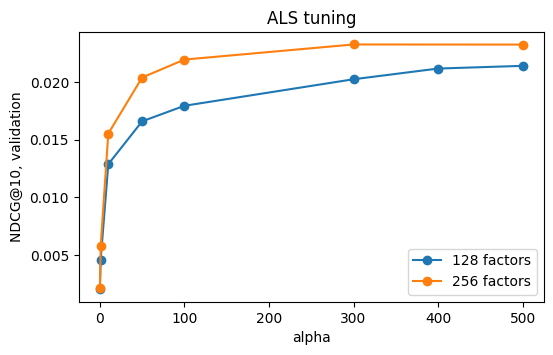

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for factors, group in als_grid.groupby("factors"):
    group = group.sort_values("alpha")
    ax.plot(group["alpha"], group["ndcg@10"], marker="o", label=f"{int(factors)} factors")
ax.set_xlabel("alpha")
ax.set_ylabel("NDCG@10, validation")
ax.set_title("ALS tuning")
ax.legend()
plt.show()

In [6]:
best_row = als_grid.sort_values("ndcg@10", ascending=False).iloc[0]
popularity_hit = baselines[(baselines["model"] == "popularity") & (baselines["metric"] == "hit@10")]["value"].iloc[0]
print(f"Best ALS on validation: hit@10 {best_row['hit@10']:.2%}, NDCG@10 {best_row['ndcg@10']:.4f}, "
      f"recall@10 {best_row['recall@10']:.2%}.")
print(f"Popularity hit@10 on validation: {popularity_hit:.2%}. ALS is about "
      f"{best_row['hit@10'] / popularity_hit:.0f} times better.")

Best ALS on validation: hit@10 4.62%, NDCG@10 0.0233, recall@10 2.48%.
Popularity hit@10 on validation: 0.28%. ALS is about 16 times better.


**What this shows:** ALS is far ahead of the baselines. Personal taste, learned from just 5 interactions,
carries much more information than popularity. One limit: the tuning grid stopped at its edge (256 factors, alpha 300),
so slightly better settings may exist.

## 7. Stage 2: LightGBM re-orders the 200 candidates

LightGBM is a ranker. It gets each candidate with five features and learns to put listings the buyer clicks above the rest.

| Feature | Meaning |
|---|---|
| `als_score` | How well the listing matches the buyer's taste, from ALS |
| `popularity` | Clicks the listing got in the first 5 interactions |
| `category_match` | Is the listing in the buyer's favourite category? |
| `county_match` | Is the listing in the buyer's favourite county? |
| `search_share` | How much of the buyer's early activity was search |

Two ways to train it, tested side by side:

- **Option A:** trained on the listings FINN showed to train buyers (clicked = 1, shown and skipped = 0).
- **Option B:** trained on ALS's own 200 candidates for train buyers (clicked later = 1, not clicked = 0).

In [7]:
lgbm_b = load("rec_lgbm_b_tuning_validation.csv").sort_values("ndcg@10", ascending=False)
lgbm_b

,hit@10,ndcg@10,recall@10,fallback_share,num_leaves,n_estimators
0,0.0488,0.0246,0.0262,0.0132,15,300
1,0.0479,0.0244,0.0263,0.0132,15,100
2,0.0485,0.0242,0.0257,0.0132,63,100
3,0.0479,0.0238,0.0256,0.0132,63,300


In [8]:
lgbm_a = load("rec_lgbm_a_tuning_validation.csv").sort_values("ndcg@10", ascending=False)
lgbm_a

,hit@10,ndcg@10,recall@10,fallback_share,num_leaves,n_estimators
0,0.0130,0.0054,0.0073,0.0132,63,300
1,0.0120,0.0053,0.0069,0.0132,63,100
2,0.0118,0.0052,0.0069,0.0132,15,300
3,0.0116,0.0051,0.0068,0.0132,15,100


Both tables are scored on validation buyers, on the same 200 candidates, with no extra information.
Compare them with ALS alone (section 6), which is the real test: does the re-ordering help?

## 8. Where option A was dropped

Option A scored well below ALS alone on the shortlist. The reason is a mismatch: it learned from lists FINN chose,
but it is asked to rank ALS candidates, which look different.

The fair test for option A is the one it was built for: **inside the lists FINN really showed**, does it put the
clicked listing higher than FINN's own order? The metric is within-slate NDCG. Option A was re-tuned on that test.

In [9]:
slate_val = load("rec_slate_check_validation.csv")
slate_val

,model,ndcg,ci_low,ci_high,diff_vs_finn,diff_low,diff_high,buyers
0,finn_order,0.5176,0.5126,0.5227,0.0000,0.0000,0.0000,4723
1,random_order,0.5003,0.4953,0.5052,-0.0174,-0.0233,-0.0115,4723
2,popularity,0.5302,0.5249,0.5355,0.0125,0.0072,0.0178,4723
3,als_score_only,0.5217,0.5165,0.5269,0.0040,-0.0014,0.0095,4723
4,lgbm_a_7leaves_50trees,0.5129,0.5078,0.5180,-0.0048,-0.0097,0.0002,4723
5,lgbm_a_7leaves_150trees,0.5128,0.5076,0.5180,-0.0048,-0.0100,0.0004,4723
6,lgbm_a_7leaves_300trees,0.5131,0.5080,0.5183,-0.0045,-0.0098,0.0008,4723
7,lgbm_a_31leaves_50trees,0.5197,0.5145,0.5249,0.0021,-0.0034,0.0075,4723
8,lgbm_a_31leaves_150trees,0.5184,0.5132,0.5235,0.0007,-0.0047,0.0061,4723
9,lgbm_a_31leaves_300trees,0.5196,0.5145,0.5248,0.0020,-0.0035,0.0075,4723


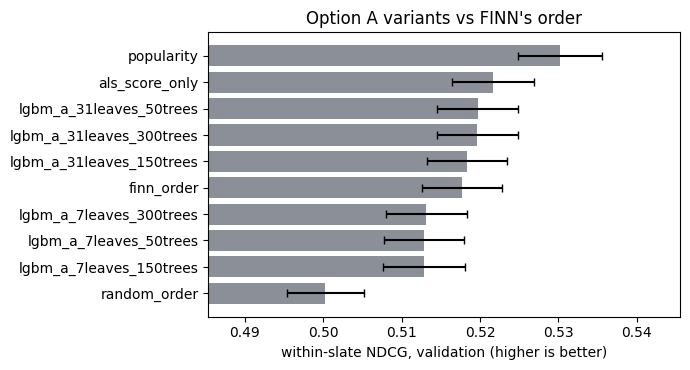

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.8))
show = slate_val.sort_values("ndcg")
ax.barh(show["model"], show["ndcg"], color=GREY,
        xerr=[show["ndcg"] - show["ci_low"], show["ci_high"] - show["ndcg"]], capsize=3)
ax.set_xlim(show["ci_low"].min() - 0.01, show["ci_high"].max() + 0.01)
ax.set_xlabel("within-slate NDCG, validation (higher is better)")
ax.set_title("Option A variants vs FINN's order")
plt.tight_layout()
plt.show()

**Decision:** even after re-tuning, option A did not beat FINN's order in a measurable way. It is not recommended.
It stays in the final test table only as a comparison.

## 9. Final test: all models, same buyers, run once

Settings are frozen. Every model builds a top 10 for each test buyer, including ALS with the popularity list as
a fallback for buyers who have no clicks in their first 5 interactions.

**Metrics** (all on the top 10):

- **hit@10:** share of buyers whose next click is in the list.
- **NDCG@10:** the same, but higher positions count more.
- **recall@10:** share of all their later clicks found in the list.

In [11]:
top10 = load("rec_eval_test_top10.csv")
table = top10.pivot(index="model", columns="metric", values="value").loc[MODEL_ORDER]
table.index = [MODEL_LABELS[m] for m in table.index]
print("Test buyers:", int(top10["buyers"].iloc[0]))
table

Test buyers: 22349


metric,hit@10,ndcg@10,recall@10
Popularity,0.0038,0.0018,0.0018
Category popularity,0.0047,0.0023,0.0025
ALS alone,0.0476,0.0255,0.0244
ALS + LightGBM A,0.0159,0.0071,0.0091
ALS + LightGBM B,0.0536,0.0284,0.0265


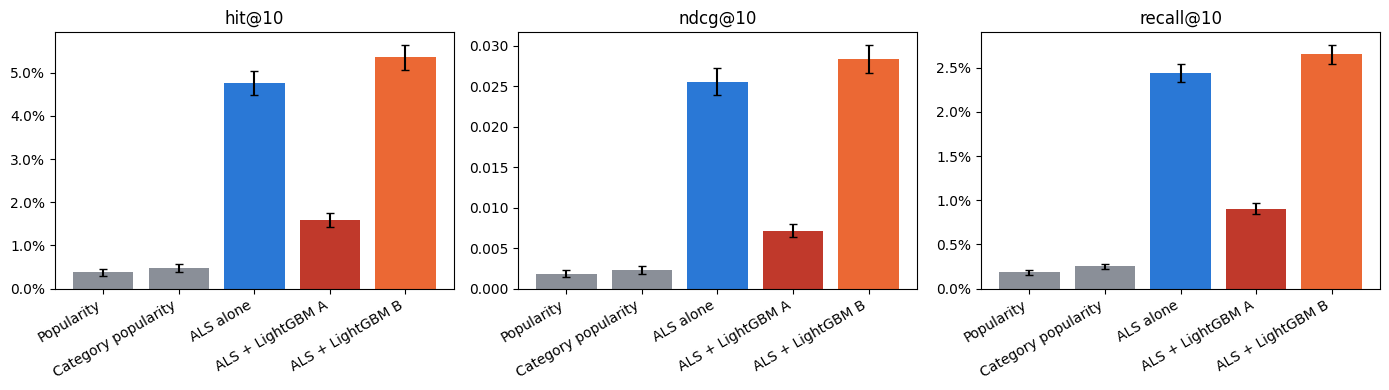

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["hit@10", "ndcg@10", "recall@10"]):
    part = top10[top10["metric"] == metric].set_index("model").loc[MODEL_ORDER]
    x = np.arange(len(part))
    ax.bar(x, part["value"], color=[MODEL_COLOURS[m] for m in part.index],
           yerr=[part["value"] - part["ci_low"], part["ci_high"] - part["value"]], capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in part.index], rotation=30, ha="right")
    ax.set_title(metric)
    if metric != "ndcg@10":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
plt.tight_layout()
plt.show()

**How to read it:** bars are the average, the lines are 95% ranges. ALS and option B are far above the baselines.
Option A sits far below ALS. B and ALS are close, so the next cell compares them properly.

### Is B really better than ALS alone?

The comparison is **paired**: for each buyer, B's score minus ALS's score, then the average. Pairing removes the
difference between easy and hard buyers, so small gaps can be measured. If the 95% range excludes zero, the gap is real.

In [13]:
differences = load("rec_eval_test_differences.csv")
differences

,comparison,metric,difference,ci_low,ci_high
0,als minus category_popularity,hit@10,0.0429,0.0400,0.0457
1,als minus category_popularity,ndcg@10,0.0232,0.0215,0.0249
2,als minus category_popularity,recall@10,0.0219,0.0208,0.0230
3,als_lgbm_b minus als,hit@10,0.0060,0.0041,0.0078
4,als_lgbm_b minus als,ndcg@10,0.0029,0.0019,0.0039
5,als_lgbm_b minus als,recall@10,0.0021,0.0015,0.0027
6,als_lgbm_a minus als,hit@10,-0.0317,-0.0345,-0.0289
7,als_lgbm_a minus als,ndcg@10,-0.0184,-0.0200,-0.0168
8,als_lgbm_a minus als,recall@10,-0.0153,-0.0163,-0.0144
9,als_lgbm_b minus als_lgbm_a,hit@10,0.0377,0.0348,0.0406


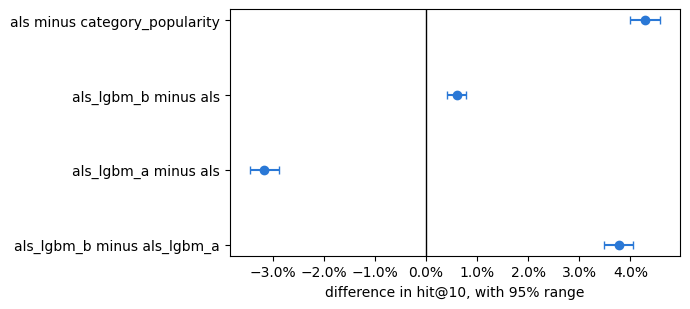

In [14]:
hit_diffs = differences[differences["metric"] == "hit@10"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7, 3.2))
y = np.arange(len(hit_diffs))
ax.errorbar(hit_diffs["difference"], y,
            xerr=[hit_diffs["difference"] - hit_diffs["ci_low"], hit_diffs["ci_high"] - hit_diffs["difference"]],
            fmt="o", color=BLUE, capsize=3)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(hit_diffs["comparison"])
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_xlabel("difference in hit@10, with 95% range")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
def diff_row(name, metric="hit@10"):
    row = differences[(differences["comparison"] == name) & (differences["metric"] == metric)].iloc[0]
    return row["difference"], row["ci_low"], row["ci_high"]

for metric in ["hit@10", "ndcg@10", "recall@10"]:
    d, lo, hi = diff_row("als_lgbm_b minus als", metric)
    verdict = "real (range excludes zero)" if lo > 0 or hi < 0 else "not clearly different from zero"
    print(f"B minus ALS, {metric}: {d:+.4f} (range {lo:+.4f} to {hi:+.4f}), {verdict}")
d, lo, hi = diff_row("als_lgbm_a minus als")
print(f"A minus ALS, hit@10: {d:+.4f} (range {lo:+.4f} to {hi:+.4f})")

B minus ALS, hit@10: +0.0060 (range +0.0041 to +0.0078), real (range excludes zero)
B minus ALS, ndcg@10: +0.0029 (range +0.0019 to +0.0039), real (range excludes zero)
B minus ALS, recall@10: +0.0021 (range +0.0015 to +0.0027), real (range excludes zero)
A minus ALS, hit@10: -0.0317 (range -0.0345 to -0.0289)


**What this shows:** option B is ahead of ALS alone on all three metrics and the ranges exclude zero, so the gain is
real. It is small in absolute terms (about half a percentage point of buyers). Option A is clearly worse than ALS.

## 10. Inside FINN's own lists (test buyers)

Same test as section 8, now on test buyers. For the real recommendation lists that had a click: how high does each
method rank the clicked listing? FINN's own order is the reference.

In [16]:
slates = load("rec_eval_test_slates.csv")
slates

,model,ndcg,ci_low,ci_high,diff_vs_finn,diff_low,diff_high,buyers
0,finn_order,0.5160,0.5125,0.5195,0.0000,0.0000,0.0000,9701
1,random_order,0.5001,0.4967,0.5036,-0.0159,-0.0200,-0.0117,9701
2,popularity,0.5286,0.5249,0.5323,0.0126,0.0089,0.0164,9701
3,als_score_only,0.5205,0.5169,0.5241,0.0045,0.0007,0.0083,9701
4,lgbm_a,0.5172,0.5136,0.5208,0.0012,-0.0026,0.0050,9701


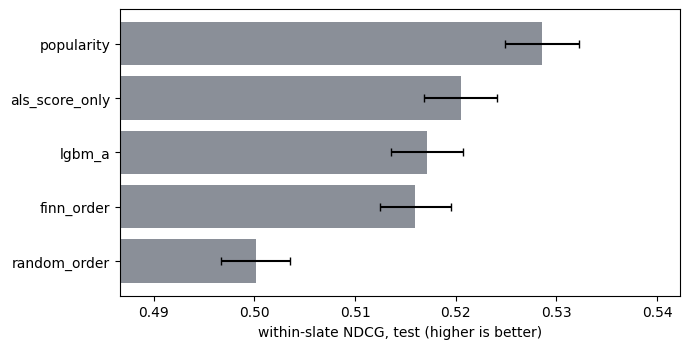

FINN order 0.5160, random 0.5001, popularity 0.5286, ALS score 0.5205, option A 0.5172.


In [17]:
fig, ax = plt.subplots(figsize=(7, 3.6))
show = slates.sort_values("ndcg")
ax.barh(show["model"], show["ndcg"], color=GREY,
        xerr=[show["ndcg"] - show["ci_low"], show["ci_high"] - show["ndcg"]], capsize=3)
ax.set_xlim(show["ci_low"].min() - 0.01, show["ci_high"].max() + 0.01)
ax.set_xlabel("within-slate NDCG, test (higher is better)")
plt.tight_layout()
plt.show()

finn = slates.set_index("model")
print(f"FINN order {finn.loc['finn_order', 'ndcg']:.4f}, random {finn.loc['random_order', 'ndcg']:.4f}, "
      f"popularity {finn.loc['popularity', 'ndcg']:.4f}, ALS score {finn.loc['als_score_only', 'ndcg']:.4f}, "
      f"option A {finn.loc['lgbm_a', 'ndcg']:.4f}.")

**What this shows:** FINN's order is only slightly better than random. Plain popularity beats it clearly. ALS score alone
is barely better, and option A is not measurably different. So option A cannot claim to improve on what FINN already shows.

## 11. Beyond accuracy: variety and popularity

A model can win on clicks and still be a popularity engine. `mart_rec_beyond_accuracy` (dbt) checks, for each model:

- **catalogue coverage:** share of recommendable listings the model ever recommends (recommendable = at least one
  click in the first 5 interactions).
- **top-1% popular share:** share of recommendations that fall on the 1% most-clicked listings. Higher means more
  popularity-driven.
- **fallback share:** share of buyers who got the popularity list because they had no early clicks.

In [18]:
beyond = query("select * from analytics_marts.mart_rec_beyond_accuracy where split_group = 'test'")
beyond = beyond.set_index("model").loc[MODEL_ORDER]
beyond.index = [MODEL_LABELS[m] for m in beyond.index]
beyond

/Users/mansi/Documents/Projects/finn-marketplace-analytics/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,split_group,buyers_scored,fallback_share,catalogue_items,distinct_items,catalogue_coverage,top1pct_popular_share
Popularity,test,22349,0.0000,190819,12,0.0001,1.0000
Category popularity,test,22349,0.0131,190819,64,0.0003,1.0000
ALS alone,test,22349,0.0131,190819,56909,0.2982,0.3758
ALS + LightGBM A,test,22349,0.0131,190819,37116,0.1945,0.5633
ALS + LightGBM B,test,22349,0.0131,190819,65392,0.3427,0.3109


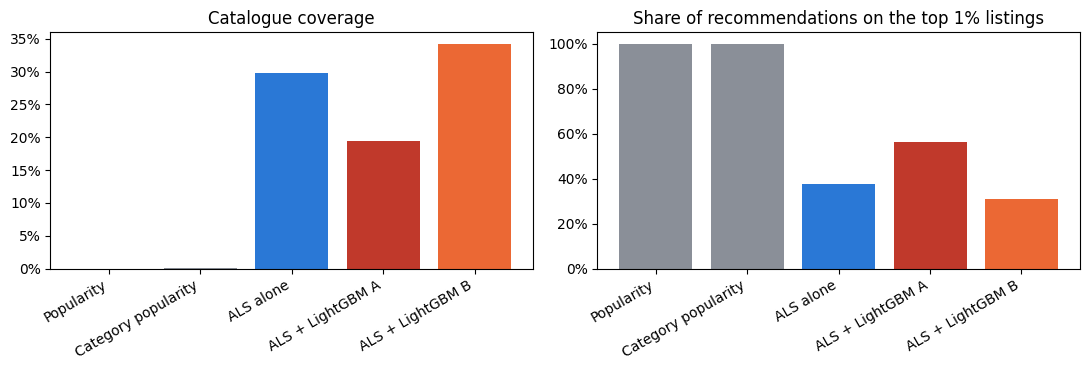

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
colours = [MODEL_COLOURS[m] for m in MODEL_ORDER]
axes[0].bar(beyond.index, beyond["catalogue_coverage"], color=colours)
axes[0].set_title("Catalogue coverage")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axes[1].bar(beyond.index, beyond["top1pct_popular_share"], color=colours)
axes[1].set_title("Share of recommendations on the top 1% listings")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()

In [20]:
b, a, al = beyond.loc["ALS + LightGBM B"], beyond.loc["ALS + LightGBM A"], beyond.loc["ALS alone"]
print(f"Option B recommends {int(b['distinct_items']):,} different listings ({b['catalogue_coverage']:.1%} coverage) "
      f"and puts {b['top1pct_popular_share']:.1%} of its picks on the top 1% listings.")
print(f"ALS alone: {int(al['distinct_items']):,} listings ({al['catalogue_coverage']:.1%}), "
      f"{al['top1pct_popular_share']:.1%} on the top 1%.")
print(f"Option A: {int(a['distinct_items']):,} listings ({a['catalogue_coverage']:.1%}), "
      f"{a['top1pct_popular_share']:.1%} on the top 1%.")

Option B recommends 65,392 different listings (34.3% coverage) and puts 31.1% of its picks on the top 1% listings.
ALS alone: 56,909 listings (29.8%), 37.6% on the top 1%.
Option A: 37,116 listings (19.5%), 56.3% on the top 1%.


**What this shows:** the two baselines recommend a tiny set of listings, all of them popular. ALS and B spread their picks
over tens of thousands of listings. B covers the most and leans on popular listings the least, so its gain over ALS does not
come from recommending more popular listings. Option A leans on popular listings the most.

## 12. Error analysis: who and what does the model get right?

The same test buyers, split into groups. For each group, the share of buyers whose next click is in the top 10 (hit@10).
Small groups are noisy, so groups with fewer than 300 buyers are left out.

In [21]:
first5 = data.first5_clicks()
later = data.later_clicks()
buyers = data.buyer_features()
items = data.item_features()

next_click, relevant = metrics.build_targets(first5, later, "test")
lists = load("rec_eval_test_lists.csv")

hit_by_model = {}
for model, group in lists.groupby("model"):
    top = group.sort_values("rank").groupby("user_id")["item_id"].agg(list).to_dict()
    hit_by_model[model] = metrics.evaluate(top, next_click, relevant).set_index("user_id")["hit"]
hits = pd.DataFrame(hit_by_model)[MODEL_ORDER]
print("Test buyers:", len(hits))
hits.mean().rename(MODEL_LABELS).to_frame("hit@10")

Test buyers: 22349


,hit@10
Popularity,0.0038
Category popularity,0.0047
ALS alone,0.0476
ALS + LightGBM A,0.0159
ALS + LightGBM B,0.0536


In [22]:
MIN_BUYERS = 300


def segment_table(column):
    grouped = hits.groupby(column, observed=True)
    table = grouped[MODEL_ORDER].mean()
    table["buyers"] = grouped.size()
    table = table[table["buyers"] >= MIN_BUYERS].copy()
    table["B minus ALS"] = table["als_lgbm_b"] - table["als"]
    return table


def plot_segment(table, title):
    fig, ax = plt.subplots(figsize=(8, 3.6))
    x = np.arange(len(table))
    width = 0.27
    for i, model in enumerate(["popularity", "als", "als_lgbm_b"]):
        ax.bar(x + (i - 1) * width, table[model], width, color=MODEL_COLOURS[model], label=MODEL_LABELS[model])
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in table.index], rotation=20, ha="right")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
    ax.set_ylabel("hit@10")
    ax.set_title(title, pad=30)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()


def say_largest_gain(table, name):
    best = table["B minus ALS"].idxmax()
    worst = table["B minus ALS"].idxmin()
    print(f"B minus ALS (hit@10, in percentage points) is highest for {name} '{best}' "
          f"({table.loc[best, 'B minus ALS'] * 100:+.2f}) and lowest for '{worst}' "
          f"({table.loc[worst, 'B minus ALS'] * 100:+.2f}).")

### 12.1 New buyers vs active buyers

Activity = how many clicks the buyer made in their first 5 interactions. Zero clicks means ALS has nothing to learn from, so the popularity list is used.

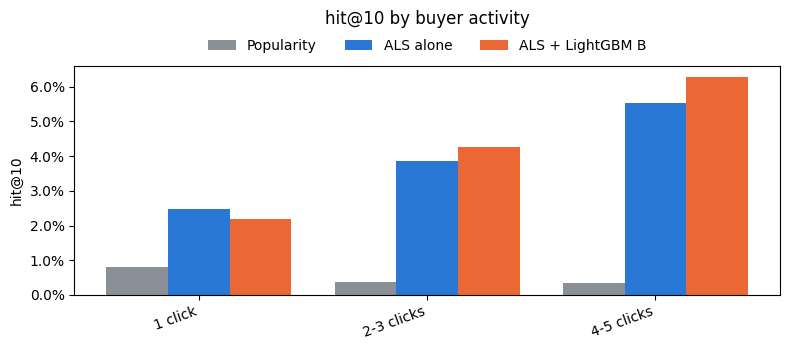

B minus ALS (hit@10, in percentage points) is highest for activity level '4-5 clicks' (+0.78) and lowest for '1 click' (-0.30).


,popularity,category_popularity,als,als_lgbm_a,als_lgbm_b,buyers,B minus ALS
activity,,,,,,,
1 click,0.0079,0.0050,0.0248,0.0069,0.0218,1008,-0.0030
2-3 clicks,0.0037,0.0048,0.0385,0.0105,0.0427,7512,0.0043
4-5 clicks,0.0034,0.0046,0.0552,0.0197,0.0629,13536,0.0078


In [23]:
hits = hits.join(buyers.set_index("user_id")[["n_first5_clicks", "top_category"]])
hits["activity"] = pd.cut(hits["n_first5_clicks"].fillna(0), [-1, 0, 1, 3, 5],
                          labels=["0 clicks (new)", "1 click", "2-3 clicks", "4-5 clicks"])
by_activity = segment_table("activity")
plot_segment(by_activity, "hit@10 by buyer activity")
say_largest_gain(by_activity, "activity level")
by_activity

### 12.2 By the buyer's favourite category

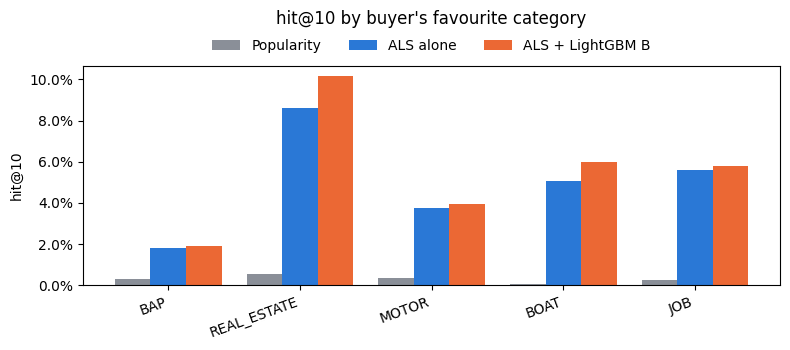

B minus ALS (hit@10, in percentage points) is highest for category 'REAL_ESTATE' (+1.53) and lowest for 'BAP' (+0.06).


,popularity,category_popularity,als,als_lgbm_a,als_lgbm_b,buyers,B minus ALS
category,,,,,,,
BAP,0.0029,0.0019,0.0182,0.0065,0.0188,6796,0.0006
REAL_ESTATE,0.0055,0.0058,0.0862,0.0302,0.1015,6716,0.0153
MOTOR,0.0036,0.0059,0.0377,0.0104,0.0393,6079,0.0016
BOAT,0.0006,0.0037,0.0505,0.0181,0.0598,1605,0.0093
JOB,0.0023,0.0105,0.0558,0.0163,0.0581,860,0.0023


In [24]:
hits["category"] = hits["top_category"].fillna("none")
by_category = segment_table("category").sort_values("buyers", ascending=False)
plot_segment(by_category, "hit@10 by buyer's favourite category")
say_largest_gain(by_category, "category")
by_category

### 12.3 Popular vs niche listings

Grouped by how popular the listing was that the buyer went on to click (clicks in the first 5 interactions of all buyers).
This shows whether a model can find listings few people click.

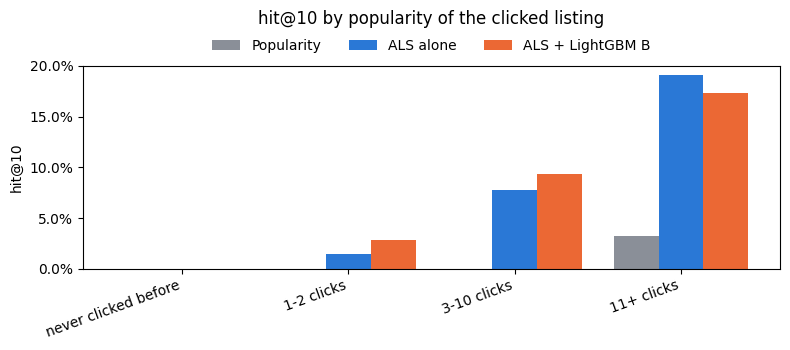

B minus ALS (hit@10, in percentage points) is highest for listing popularity '3-10 clicks' (+1.64) and lowest for '11+ clicks' (-1.71).


,popularity,category_popularity,als,als_lgbm_a,als_lgbm_b,buyers,B minus ALS
target_popularity,,,,,,,
never clicked before,0.0000,0.0000,0.0000,0.0001,0.0000,7595,0.0000
1-2 clicks,0.0000,0.0000,0.0148,0.0022,0.0279,6025,0.0131
3-10 clicks,0.0000,0.0000,0.0773,0.0243,0.0937,6091,0.0164
11+ clicks,0.0318,0.0398,0.1907,0.0732,0.1736,2638,-0.0171


In [25]:
target_popularity = pd.Series(next_click).map(items.set_index("item_id")["n_clicks_first5"]).fillna(0)
hits["target_popularity"] = pd.cut(target_popularity.reindex(hits.index), [-1, 0, 2, 10, np.inf],
                                   labels=["never clicked before", "1-2 clicks", "3-10 clicks", "11+ clicks"])
by_popularity = segment_table("target_popularity")
plot_segment(by_popularity, "hit@10 by popularity of the clicked listing")
say_largest_gain(by_popularity, "listing popularity")
by_popularity

**Reading these tables:** each row is a group of test buyers. A model is doing well where its hit@10 is high. The last column
shows where B's gain over ALS is concentrated. Differences between groups are descriptive, not tested one by one, so use them
to decide where to look next, not as proven effects.

**Not included:** LightGBM feature importance. The trained model is not saved between runs, so it cannot be read here.

## 13. Conclusion: is a live A/B test justified?

**What we found (test buyers, run once):**

- ALS alone finds the buyer's next click in the top 10 for 4.76% of buyers, against 0.38% for popularity and 0.47% for category popularity.
- ALS + LightGBM option B reaches 5.36%. The gain over ALS is +0.60 percentage points (95% range 0.41 to 0.78), also ahead on NDCG and recall, and every range excludes zero. Small but real.
- Option A (trained on FINN's slates) scores 1.59%, well below ALS. Inside FINN's own lists it does not beat FINN's order. Dropped.
- B's gain does not come from recommending popular listings: it covers the most listings and leans the least on the most-clicked 1% compared to other options (31%, against 38% for ALS and 56% for option A).
- **Ceiling:** 34% of test buyers click a listing nobody clicked in their first 5 interactions. Every recommender scores 0% on them, so no model can find more than about 66% of buyers' next clicks.


<!-- - **Where B gains over ALS:** on niche listings (1–10 earlier clicks: +1.3 to +1.6 points), in real estate (+1.53 points) and for buyers with 4–5 early clicks (+0.78 points).
- **Where B does worse than ALS:** for buyers with 1 early click (−0.30 points) and for buyers whose next click is an already popular listing (11+ clicks: −1.71 points).
- **No gain in some groups:** in BAP (+0.06 points), B is about equal to ALS. -->

**Where B gains or loses against ALS** (hit@10, percentage points):
| Result | Group of buyers | B minus ALS |
|---|---|---|
| Gains | Next click is a niche listing (1–2 earlier clicks) | +1.31 |
| Gains | Next click is a niche listing (3–10 earlier clicks) | +1.64 |
| Gains | Real estate buyers | +1.53 |
| Gains | Buyers with 4–5 early clicks | +0.78 |
| No gain | BAP buyers | +0.06 |
| Worse | Buyers with 1 early click | −0.30 |
| Worse | Next click is an already popular listing (11+ earlier clicks) | −1.71 |

The group differences are descriptive: they were not tested one by one.

**Recommendation:** use ALS + option B. The offline gain over ALS is small and measured on past clicks, so it supports a live A/B test
(using the Part 2 method), not a full launch. Ranking against the simple baselines is a large win and would be worth testing on its own.

**What a live test would need:**

- Randomise buyers between the current list and the B list, and log the slate, position and click for each buyer.
- Primary metric: click rate on recommendation slates. Guardrail: buyers' overall clicking must not drop.
- The offline metric (next click in the top 10) is not the live metric, so the sample size must be recalculated with the Part 2 power method.

## 14. Limitations

- **No timestamps:** popularity is counted from first-5 interactions of all buyers, so it may partly see the future.
- **ALS factors tested only up to 256:** 256 beat 128 at every alpha, so more factors might help. Alpha reached a plateau between 300 and 500.
- **Exposure bias:** clicks exist only on listings FINN showed, so the data favours what FINN already recommends.
- **Option A mismatch:** it trained on FINN's lists but was scored on ALS candidates.
- **Offline only:** hit rate on past clicks is a proxy for what buyers would do with new lists.
- **Small buyer groups:** the segment results in section 12 are descriptive.

## 15. Where everything lives

| What | Where |
|---|---|
| Code | `recommender/` (modules, run scripts, tests) |
| Results files | `analysis/results/rec_*.csv` and `rec_*_params.json` |
| Top 10 lists per model | Snowflake `RAW.RECOMMENDER.SCORES` |
| Variety and popularity check | dbt model `mart_rec_beyond_accuracy` |